In [1]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 1: ENVIRONMENT SETUP
# ============================================================

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from PIL import Image

print("=" * 60)
print("MODEL 2A - ENVIRONMENT SETUP")
print("=" * 60)

print("Python version      :", sys.version)
print("PyTorch version     :", torch.__version__)
print("Torchvision version :", torchvision.__version__)

print("\nGPU available       :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU                 :",
          torch.cuda.get_device_name(0))

    print("CUDA version        :",
          torch.version.cuda)

    device = torch.device("cuda")

else:

    print("GPU                 : Not available")

    device = torch.device("cpu")


print("\nUsing device        :", device)

print("=" * 60)

MODEL 2A - ENVIRONMENT SETUP
Python version      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version     : 2.11.0+cu128
Torchvision version : 0.26.0+cu128

GPU available       : True
GPU                 : Tesla T4
CUDA version        : 12.8

Using device        : cuda


In [2]:
!pip install -q kaggle

In [2]:
import kaggle

print("Kaggle package imported successfully")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [4]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move(
    "kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    0o600
)

print("✅ Kaggle API configured successfully")

✅ Kaggle API configured successfully


In [5]:
!kaggle datasets list -s "brain tumor multimodal image CT MRI" | head

ref                                                           title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
murtozalikhon/brain-tumor-multimodal-image-ct-and-mri         Brain tumor multimodal image (CT & MRI)             378311120  2024-12-03 12:48:16.463000           7553         80                1  
muhammethekimayvaz/clean-hybrid-brain-mri-dataset             Clean Hybrid Brain MRI Dataset                       77240730  2026-05-02 17:47:34.787000             13          9            0.875  
mohamedaymanhassan/brain-tumor-images-classification-by-cnn   Brain Tumor images Classification by CNN            378330360  2026-05-09 06:18:23.630000             13          0           0.5625  
ranitroy2005/br

In [6]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 3: DOWNLOAD DATASET
# ============================================================

!kaggle datasets download \
    -d murtozalikhon/brain-tumor-multimodal-image-ct-and-mri \
    -p /content

Dataset URL: https://www.kaggle.com/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri
License(s): CC-BY-NC-SA-4.0
100% 361M/361M [00:03<00:00, 99.7MB/s]



In [7]:
import os

zip_path = "/content/brain-tumor-multimodal-image-ct-and-mri.zip"

print("=" * 60)
print("DATASET DOWNLOAD VERIFICATION")
print("=" * 60)

if os.path.exists(zip_path):

    size_mb = os.path.getsize(zip_path) / (1024 * 1024)

    print("✅ Dataset downloaded successfully")
    print("Path :", zip_path)
    print(f"Size : {size_mb:.2f} MB")

else:

    print("❌ Dataset ZIP was not found")

DATASET DOWNLOAD VERIFICATION
✅ Dataset downloaded successfully
Path : /content/brain-tumor-multimodal-image-ct-and-mri.zip
Size : 360.79 MB


In [8]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 4: EXTRACT DATASET
# ============================================================

import os
import zipfile

zip_path = "/content/brain-tumor-multimodal-image-ct-and-mri.zip"
extract_path = "/content/brain_dataset"

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract dataset
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("=" * 60)
print("DATASET EXTRACTION")
print("=" * 60)
print("✅ Dataset extracted successfully")
print("Extraction path:", extract_path)

DATASET EXTRACTION
✅ Dataset extracted successfully
Extraction path: /content/brain_dataset


In [9]:
# ============================================================
# VERIFY EXTRACTED STRUCTURE
# ============================================================

import os

print("=" * 70)
print("EXTRACTED DATASET STRUCTURE")
print("=" * 70)

for root, dirs, files in os.walk("/content/brain_dataset"):

    level = root.replace(
        "/content/brain_dataset", ""
    ).count(os.sep)

    if level <= 4:

        indent = "    " * level

        print(
            indent + os.path.basename(root) + "/"
        )

EXTRACTED DATASET STRUCTURE
brain_dataset/
    Dataset/
        Brain Tumor MRI images/
            Healthy/
            Tumor/
        Brain Tumor CT scan Images/
            Healthy/
            Tumor/


In [10]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 5: VERIFY MRI IMAGE COUNTS
# ============================================================

import os

MRI_DIR = "/content/brain_dataset/Dataset/Brain Tumor MRI images"

HEALTHY_DIR = os.path.join(
    MRI_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    MRI_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def get_image_files(folder):

    return [
        os.path.join(folder, filename)
        for filename in os.listdir(folder)
        if (
            os.path.isfile(
                os.path.join(folder, filename)
            )
            and filename.lower().endswith(
                VALID_EXTENSIONS
            )
        )
    ]


# Get image paths
healthy_images = get_image_files(HEALTHY_DIR)
tumor_images = get_image_files(TUMOR_DIR)


# Counts
healthy_count = len(healthy_images)
tumor_count = len(tumor_images)
total_count = healthy_count + tumor_count


# Display
print("=" * 70)
print("MODEL 2A - MRI DATASET VERIFICATION")
print("=" * 70)

print("\nMRI Healthy images :", healthy_count)
print("MRI Tumor images   :", tumor_count)
print("Total MRI images   :", total_count)

print("\nExpected:")
print("MRI Healthy : 2000")
print("MRI Tumor   : 3000")
print("Total MRI   : 5000")

print("\n" + "=" * 70)

if healthy_count == 2000 and tumor_count == 3000:
    print("✅ MRI DATASET VERIFIED SUCCESSFULLY")
else:
    print("⚠️ COUNT DOES NOT MATCH EXPECTED VALUES")

print("=" * 70)

MODEL 2A - MRI DATASET VERIFICATION

MRI Healthy images : 2000
MRI Tumor images   : 3000
Total MRI images   : 5000

Expected:
MRI Healthy : 2000
MRI Tumor   : 3000
Total MRI   : 5000

✅ MRI DATASET VERIFIED SUCCESSFULLY


MODEL 2A - MRI IMAGE INSPECTION

HEALTHY MRI
----------------------------------------
Filename : mri_healthy (794).jpg
Path     : /content/brain_dataset/Dataset/Brain Tumor MRI images/Healthy/mri_healthy (794).jpg
Format   : JPEG
Size     : (235, 227)
Mode     : RGB

TUMOR MRI
----------------------------------------
Filename : meningioma (730).jpg
Path     : /content/brain_dataset/Dataset/Brain Tumor MRI images/Tumor/meningioma (730).jpg
Format   : JPEG
Size     : (528, 581)
Mode     : RGB


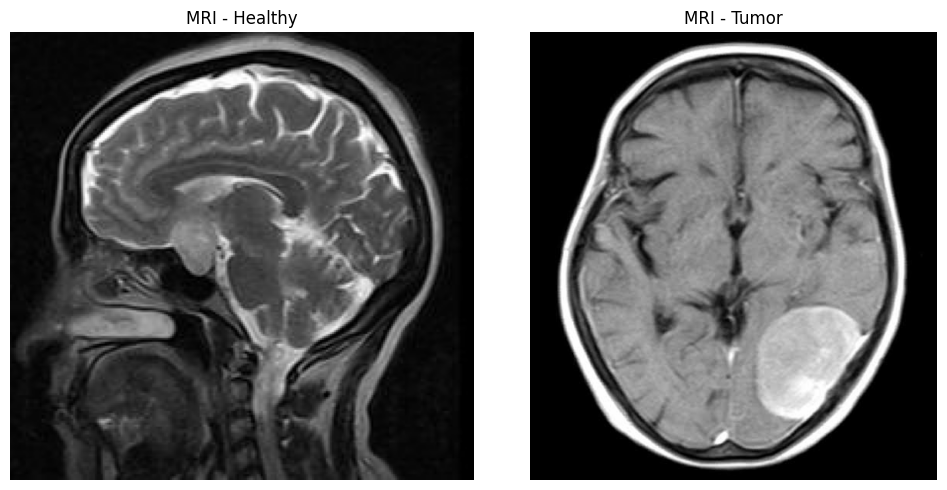

In [11]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 6: INSPECT MRI IMAGES
# ============================================================

from PIL import Image
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MRI_DIR = "/content/brain_dataset/Dataset/Brain Tumor MRI images"

HEALTHY_DIR = os.path.join(MRI_DIR, "Healthy")
TUMOR_DIR = os.path.join(MRI_DIR, "Tumor")


# ------------------------------------------------------------
# Get sample files
# ------------------------------------------------------------

healthy_files = [
    f for f in os.listdir(HEALTHY_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

tumor_files = [
    f for f in os.listdir(TUMOR_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]


# ------------------------------------------------------------
# Select one image from each class
# ------------------------------------------------------------

healthy_path = os.path.join(
    HEALTHY_DIR,
    healthy_files[0]
)

tumor_path = os.path.join(
    TUMOR_DIR,
    tumor_files[0]
)


# ------------------------------------------------------------
# Open images
# ------------------------------------------------------------

healthy_image = Image.open(healthy_path)
tumor_image = Image.open(tumor_path)


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2A - MRI IMAGE INSPECTION")
print("=" * 70)

print("\nHEALTHY MRI")
print("-" * 40)
print("Filename :", healthy_files[0])
print("Path     :", healthy_path)
print("Format   :", healthy_image.format)
print("Size     :", healthy_image.size)
print("Mode     :", healthy_image.mode)

print("\nTUMOR MRI")
print("-" * 40)
print("Filename :", tumor_files[0])
print("Path     :", tumor_path)
print("Format   :", tumor_image.format)
print("Size     :", tumor_image.size)
print("Mode     :", tumor_image.mode)


# ------------------------------------------------------------
# Display images
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(healthy_image, cmap="gray")
plt.title("MRI - Healthy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tumor_image, cmap="gray")
plt.title("MRI - Tumor")
plt.axis("off")

plt.tight_layout()
plt.show()

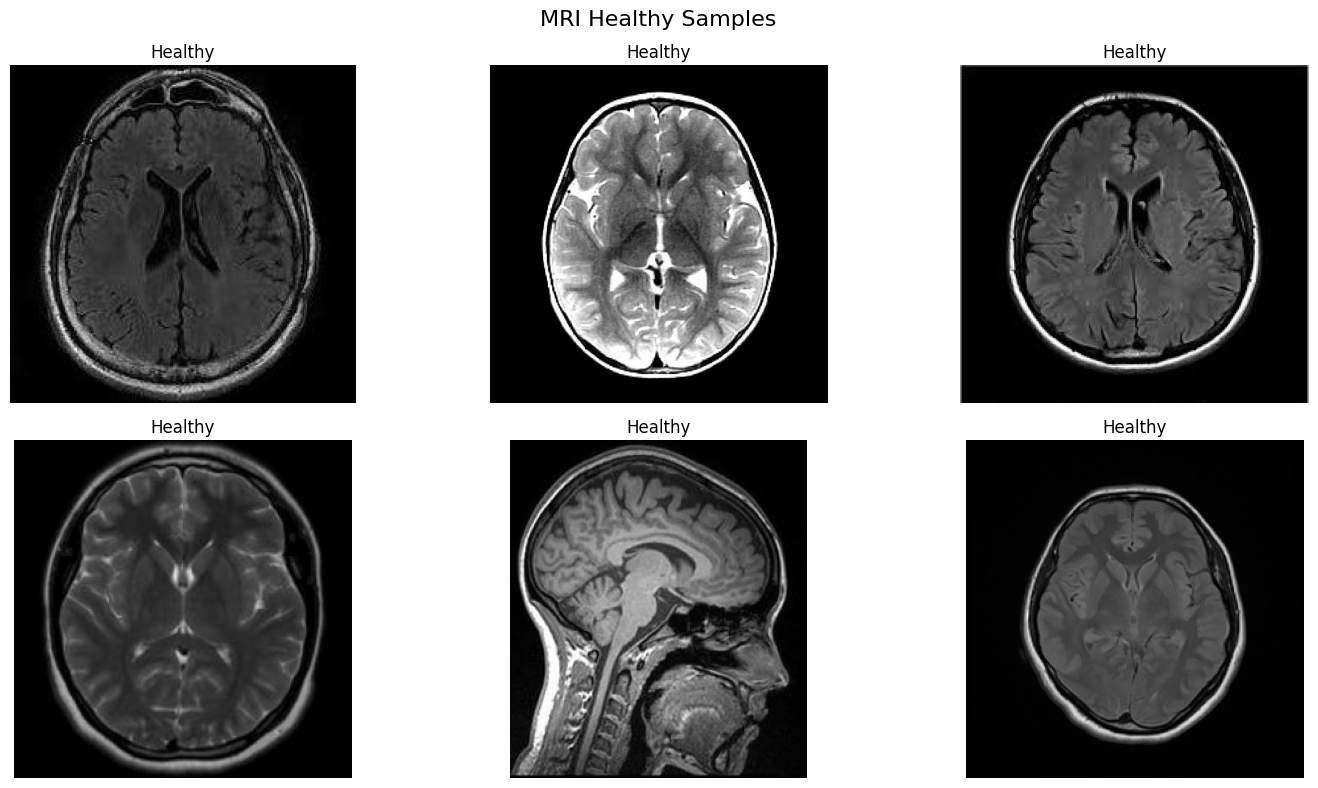

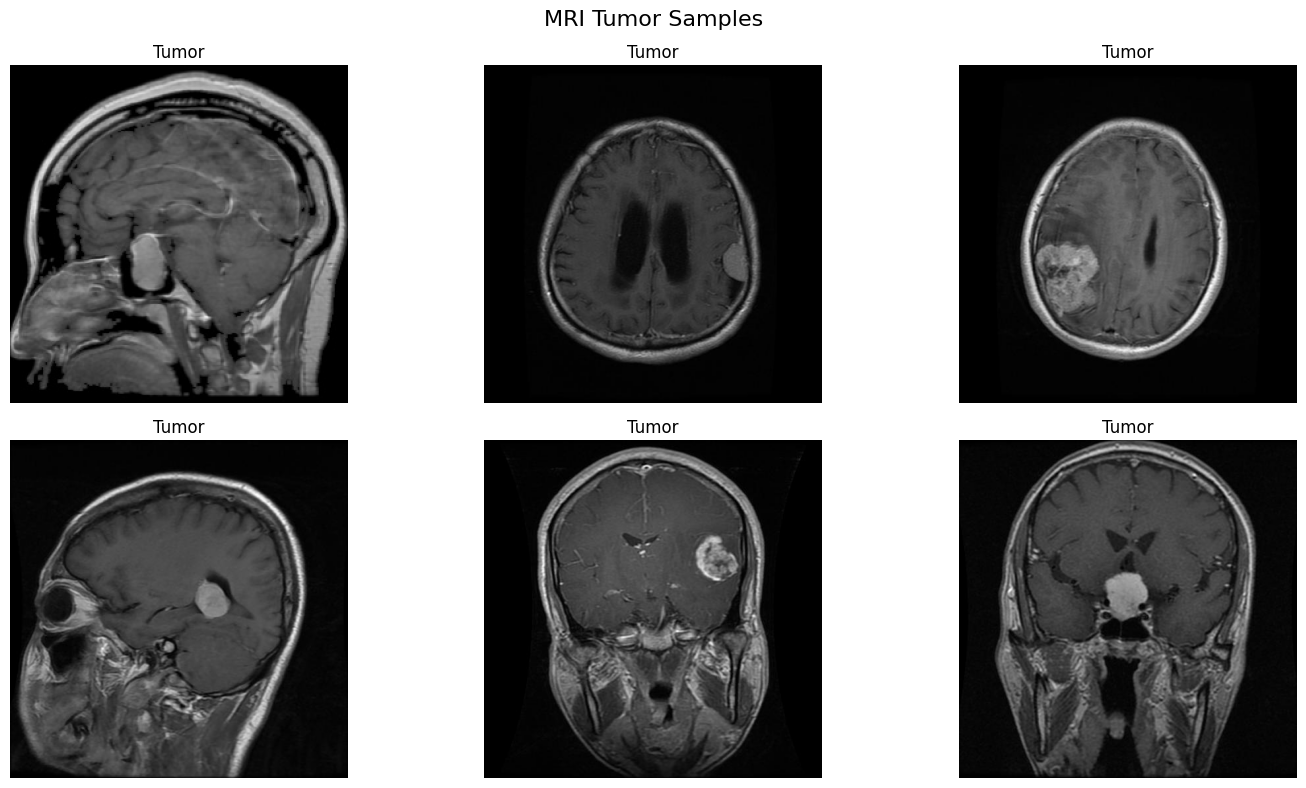

In [12]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 7: VISUAL DATASET INSPECTION
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

MRI_DIR = "/content/brain_dataset/Dataset/Brain Tumor MRI images"

HEALTHY_DIR = os.path.join(
    MRI_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    MRI_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ------------------------------------------------------------
# Get image files
# ------------------------------------------------------------

healthy_files = [
    os.path.join(HEALTHY_DIR, f)
    for f in os.listdir(HEALTHY_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]

tumor_files = [
    os.path.join(TUMOR_DIR, f)
    for f in os.listdir(TUMOR_DIR)
    if f.lower().endswith(VALID_EXTENSIONS)
]


# ------------------------------------------------------------
# Select random samples
# ------------------------------------------------------------

random.seed(42)

healthy_samples = random.sample(
    healthy_files,
    6
)

tumor_samples = random.sample(
    tumor_files,
    6
)


# ------------------------------------------------------------
# Display Healthy MRI images
# ------------------------------------------------------------

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(healthy_samples):

    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title("Healthy")

    plt.axis("off")

plt.suptitle(
    "MRI Healthy Samples",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Display Tumor MRI images
# ------------------------------------------------------------

plt.figure(figsize=(15, 8))

for i, image_path in enumerate(tumor_samples):

    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title("Tumor")

    plt.axis("off")

plt.suptitle(
    "MRI Tumor Samples",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 8: CREATE DATAFRAME
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Dataset paths
# ------------------------------------------------------------

MRI_DIR = "/content/brain_dataset/Dataset/Brain Tumor MRI images"

HEALTHY_DIR = os.path.join(
    MRI_DIR,
    "Healthy"
)

TUMOR_DIR = os.path.join(
    MRI_DIR,
    "Tumor"
)

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


# ------------------------------------------------------------
# Create dataset records
# ------------------------------------------------------------

data = []


# ------------------------------------------------------------
# Healthy images → label 0
# ------------------------------------------------------------

for filename in os.listdir(HEALTHY_DIR):

    filepath = os.path.join(
        HEALTHY_DIR,
        filename
    )

    if (
        os.path.isfile(filepath)
        and filename.lower().endswith(VALID_EXTENSIONS)
    ):

        data.append({
            "filepath": filepath,
            "label": 0,
            "class_name": "Healthy"
        })


# ------------------------------------------------------------
# Tumor images → label 1
# ------------------------------------------------------------

for filename in os.listdir(TUMOR_DIR):

    filepath = os.path.join(
        TUMOR_DIR,
        filename
    )

    if (
        os.path.isfile(filepath)
        and filename.lower().endswith(VALID_EXTENSIONS)
    ):

        data.append({
            "filepath": filepath,
            "label": 1,
            "class_name": "Tumor"
        })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(data)


# ------------------------------------------------------------
# Shuffle dataset
# ------------------------------------------------------------

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2A - MRI DATAFRAME")
print("=" * 70)

print("\nTotal images:", len(df))

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nDataFrame shape:")
print(df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

MODEL 2A - MRI DATAFRAME

Total images: 5000

Class distribution:
class_name
Tumor      3000
Healthy    2000
Name: count, dtype: int64

Label distribution:
label
1    3000
0    2000
Name: count, dtype: int64

DataFrame shape:
(5000, 3)

First 10 rows:


,filepath,label,class_name
0,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy
1,/content/brain_dataset/Dataset/Brain Tumor MRI...,1,Tumor
2,/content/brain_dataset/Dataset/Brain Tumor MRI...,1,Tumor
3,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy
4,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy
5,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy
6,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy
7,/content/brain_dataset/Dataset/Brain Tumor MRI...,1,Tumor
8,/content/brain_dataset/Dataset/Brain Tumor MRI...,1,Tumor
9,/content/brain_dataset/Dataset/Brain Tumor MRI...,0,Healthy


In [14]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 9: LABEL AND DATASET VALIDATION
# ============================================================

import os

print("=" * 70)
print("MODEL 2A - LABEL VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic counts
# ------------------------------------------------------------

print("\nTotal images:", len(df))

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts())


# ------------------------------------------------------------
# 2. Verify label mapping
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LABEL MAPPING")
print("=" * 70)

mapping = df.groupby(
    ["class_name", "label"]
).size()

print(mapping)


# ------------------------------------------------------------
# 3. Check expected mapping
# ------------------------------------------------------------

healthy_correct = (
    (df["class_name"] == "Healthy") &
    (df["label"] == 0)
).sum()

healthy_wrong = (
    (df["class_name"] == "Healthy") &
    (df["label"] != 0)
).sum()

tumor_correct = (
    (df["class_name"] == "Tumor") &
    (df["label"] == 1)
).sum()

tumor_wrong = (
    (df["class_name"] == "Tumor") &
    (df["label"] != 1)
).sum()


print("\nHealthy correctly labeled :", healthy_correct)
print("Healthy incorrectly labeled:", healthy_wrong)

print("\nTumor correctly labeled   :", tumor_correct)
print("Tumor incorrectly labeled :", tumor_wrong)


# ------------------------------------------------------------
# 4. Check missing files
# ------------------------------------------------------------

missing_files = df[
    ~df["filepath"].apply(os.path.exists)
]

print("\n" + "=" * 70)
print("FILE EXISTENCE CHECK")
print("=" * 70)

print("Missing files:", len(missing_files))


# ------------------------------------------------------------
# 5. Check duplicate paths
# ------------------------------------------------------------

duplicate_paths = df[
    df["filepath"].duplicated()
]

print("\nDuplicate file paths:", len(duplicate_paths))


# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

if (
    len(df) == 5000
    and healthy_correct == 2000
    and tumor_correct == 3000
    and healthy_wrong == 0
    and tumor_wrong == 0
    and len(missing_files) == 0
    and len(duplicate_paths) == 0
):

    print("✅ DATASET VALIDATION PASSED")

else:

    print("⚠️ DATASET VALIDATION FAILED")

print("=" * 70)

MODEL 2A - LABEL VALIDATION

Total images: 5000

Class distribution:
class_name
Tumor      3000
Healthy    2000
Name: count, dtype: int64

Label distribution:
label
1    3000
0    2000
Name: count, dtype: int64

LABEL MAPPING
class_name  label
Healthy     0        2000
Tumor       1        3000
dtype: int64

Healthy correctly labeled : 2000
Healthy incorrectly labeled: 0

Tumor correctly labeled   : 3000
Tumor incorrectly labeled : 0

FILE EXISTENCE CHECK
Missing files: 0

Duplicate file paths: 0

FINAL VALIDATION
✅ DATASET VALIDATION PASSED


In [15]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 10: TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# First split:
# 70% Training
# 30% Temporary
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


# ------------------------------------------------------------
# Second split:
# Temporary → 50% Validation + 50% Test
#
# Therefore:
# 30% × 50% = 15% Validation
# 30% × 50% = 15% Test
# ------------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)


# ------------------------------------------------------------
# Reset indexes
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# ------------------------------------------------------------
# Display sizes
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2A - DATASET SPLIT")
print("=" * 70)

print("\nDataset sizes:")
print("Training   :", len(train_df))
print("Validation :", len(val_df))
print("Testing    :", len(test_df))
print("Total      :", len(train_df) + len(val_df) + len(test_df))


# ------------------------------------------------------------
# Display class distributions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING DISTRIBUTION")
print("=" * 70)

print(
    train_df["class_name"].value_counts()
)


print("\n" + "=" * 70)
print("VALIDATION DISTRIBUTION")
print("=" * 70)

print(
    val_df["class_name"].value_counts()
)


print("\n" + "=" * 70)
print("TEST DISTRIBUTION")
print("=" * 70)

print(
    test_df["class_name"].value_counts()
)

MODEL 2A - DATASET SPLIT

Dataset sizes:
Training   : 3500
Validation : 750
Testing    : 750
Total      : 5000

TRAINING DISTRIBUTION
class_name
Tumor      2100
Healthy    1400
Name: count, dtype: int64

VALIDATION DISTRIBUTION
class_name
Tumor      450
Healthy    300
Name: count, dtype: int64

TEST DISTRIBUTION
class_name
Tumor      450
Healthy    300
Name: count, dtype: int64


In [16]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 11: IMAGE PREPROCESSING & AUGMENTATION
# ============================================================

import torch
from torchvision import transforms

# ------------------------------------------------------------
# ImageNet normalization
# ------------------------------------------------------------

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([

    # Ensure every image becomes RGB
    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    # Resize to EfficientNet-B0 input size
    transforms.Resize(
        (224, 224)
    ),

    # Moderate augmentation
    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    # Convert PIL image → Tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation transformations
# ------------------------------------------------------------

val_transform = transforms.Compose([

    # Ensure RGB
    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    # Resize
    transforms.Resize(
        (224, 224)
    ),

    # Convert to Tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test transformations
# ------------------------------------------------------------

test_transform = transforms.Compose([

    # Ensure RGB
    transforms.Lambda(
        lambda img: img.convert("RGB")
    ),

    # Resize
    transforms.Resize(
        (224, 224)
    ),

    # Convert to Tensor
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Display transform information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2A - IMAGE TRANSFORMS")
print("=" * 70)

print("\nTraining transformations:")
print(train_transform)

print("\nValidation transformations:")
print(val_transform)

print("\nTest transformations:")
print(test_transform)

print("\nImage size: 224 × 224")
print("Channels  : 3 (RGB)")
print("Normalization: ImageNet")

MODEL 2A - IMAGE TRANSFORMS

Training transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transformations:
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Image size: 224 × 224
Channels  : 3 (RGB)
Normalization: ImageNet


In [17]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 12: PYTORCH DATASET
# ============================================================

import torch
from torch.utils.data import Dataset
from PIL import Image


class MRITumorDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        # ----------------------------------------------------
        # Get image path and label
        # ----------------------------------------------------

        image_path = self.dataframe.loc[
            index,
            "filepath"
        ]

        label = self.dataframe.loc[
            index,
            "label"
        ]


        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = Image.open(
            image_path
        ).convert("RGB")


        # ----------------------------------------------------
        # Apply transformation
        # ----------------------------------------------------

        if self.transform is not None:

            image = self.transform(image)


        # ----------------------------------------------------
        # Convert label to tensor
        # ----------------------------------------------------

        label = torch.tensor(
            label,
            dtype=torch.long
        )


        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = MRITumorDataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = MRITumorDataset(
    dataframe=val_df,
    transform=val_transform
)

test_dataset = MRITumorDataset(
    dataframe=test_df,
    transform=test_transform
)


# ============================================================
# VERIFY DATASET SIZES
# ============================================================

print("=" * 70)
print("MODEL 2A - PYTORCH DATASET")
print("=" * 70)

print("\nTraining dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Test dataset       :", len(test_dataset))

MODEL 2A - PYTORCH DATASET

Training dataset   : 3500
Validation dataset : 750
Test dataset       : 750


In [18]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 13: VERIFY TRANSFORMED SAMPLE
# ============================================================

import torch

print("=" * 70)
print("MODEL 2A - TRANSFORMED SAMPLE VERIFICATION")
print("=" * 70)

# Get one training sample
image, label = train_dataset[0]

print("\nImage information:")
print("Type  :", type(image))
print("Shape :", image.shape)
print("Dtype :", image.dtype)

print("\nLabel information:")
print("Type  :", type(label))
print("Value :", label.item())
print("Dtype :", label.dtype)

# ------------------------------------------------------------
# Verify expected values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

if (
    isinstance(image, torch.Tensor)
    and image.shape == (3, 224, 224)
    and image.dtype == torch.float32
    and label.item() in [0, 1]
):

    print("✅ TRANSFORMED SAMPLE VERIFIED")

else:

    print("⚠️ SOMETHING IS INCORRECT")

print("=" * 70)

MODEL 2A - TRANSFORMED SAMPLE VERIFICATION

Image information:
Type  : <class 'torch.Tensor'>
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32

Label information:
Type  : <class 'torch.Tensor'>
Value : 1
Dtype : torch.int64

VERIFICATION
✅ TRANSFORMED SAMPLE VERIFIED


In [19]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 14: CREATE DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 32
NUM_WORKERS = 2

# ------------------------------------------------------------
# Training DataLoader
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ------------------------------------------------------------
# Validation DataLoader
# ------------------------------------------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ------------------------------------------------------------
# Test DataLoader
# ------------------------------------------------------------

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 70)
print("MODEL 2A - DATALOADERS")
print("=" * 70)

print("\nBatch size    :", BATCH_SIZE)
print("Num workers   :", NUM_WORKERS)

print("\nTraining batches   :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))

MODEL 2A - DATALOADERS

Batch size    : 32
Num workers   : 2

Training batches   : 110
Validation batches : 24
Test batches       : 24


In [20]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 15: VERIFY DATALOADER BATCH
# ============================================================

print("=" * 70)
print("MODEL 2A - BATCH VERIFICATION")
print("=" * 70)

# Get one batch
images, labels = next(iter(train_loader))

print("\nImages:")
print("Shape :", images.shape)
print("Dtype :", images.dtype)

print("\nLabels:")
print("Shape :", labels.shape)
print("Dtype :", labels.dtype)
print("Values:", labels[:10])

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

expected_shape = (BATCH_SIZE, 3, 224, 224)

if (
    images.shape == expected_shape
    and labels.shape[0] == BATCH_SIZE
    and images.dtype == torch.float32
    and labels.dtype == torch.int64
):

    print("✅ DATALOADER BATCH VERIFIED")

else:

    print("⚠️ BATCH DOES NOT MATCH EXPECTED FORMAT")

print("=" * 70)

MODEL 2A - BATCH VERIFICATION

Images:
Shape : torch.Size([32, 3, 224, 224])
Dtype : torch.float32

Labels:
Shape : torch.Size([32])
Dtype : torch.int64
Values: tensor([0, 1, 1, 1, 1, 1, 0, 0, 1, 1])

VERIFICATION
✅ DATALOADER BATCH VERIFIED


In [21]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 16: LOAD PRETRAINED EFFICIENTNET-B0
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

print("=" * 70)
print("MODEL 2A - EFFICIENTNET-B0")
print("=" * 70)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nUsing device:", device)


# ------------------------------------------------------------
# Load pretrained EfficientNet-B0
# ------------------------------------------------------------

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)


# ------------------------------------------------------------
# Display original classifier
# ------------------------------------------------------------

print("\nOriginal classifier:")
print(model.classifier)


# ------------------------------------------------------------
# Get input features of final layer
# ------------------------------------------------------------

num_features = model.classifier[1].in_features

print("\nClassifier input features:", num_features)


# ------------------------------------------------------------
# Replace classifier
# ------------------------------------------------------------

model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.2
    ),

    nn.Linear(
        num_features,
        2
    )
)


# ------------------------------------------------------------
# Move model to GPU
# ------------------------------------------------------------

model = model.to(device)


# ------------------------------------------------------------
# Display new classifier
# ------------------------------------------------------------

print("\nNew classifier:")
print(model.classifier)

print("\n" + "=" * 70)
print("MODEL READY")
print("=" * 70)

MODEL 2A - EFFICIENTNET-B0

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 57.0MB/s]



Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Classifier input features: 1280

New classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

MODEL READY


In [22]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 17: FORWARD PASS VERIFICATION
# ============================================================

import torch

print("=" * 70)
print("MODEL 2A - FORWARD PASS VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Get one batch
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nInput batch:")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)


# ------------------------------------------------------------
# Move images to GPU
# ------------------------------------------------------------

images = images.to(device)
labels = labels.to(device)


# ------------------------------------------------------------
# Evaluation mode for verification
# ------------------------------------------------------------

model.eval()


# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------

with torch.no_grad():

    outputs = model(images)


# ------------------------------------------------------------
# Display output
# ------------------------------------------------------------

print("\nModel output:")
print("Output shape :", outputs.shape)

print("\nFirst 5 output logits:")
print(outputs[:5])

print("\nFirst 5 labels:")
print(labels[:5])


# ------------------------------------------------------------
# Verify output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VERIFICATION")
print("=" * 70)

expected_output_shape = (
    images.shape[0],
    2
)

if outputs.shape == expected_output_shape:

    print("✅ FORWARD PASS SUCCESSFUL")

else:

    print("⚠️ OUTPUT SHAPE IS INCORRECT")

print("=" * 70)

MODEL 2A - FORWARD PASS VERIFICATION

Input batch:
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])

Model output:
Output shape : torch.Size([32, 2])

First 5 output logits:
tensor([[ 0.1537, -0.4019],
        [ 0.2493, -0.3804],
        [ 0.2786, -0.5990],
        [-0.3603, -0.5194],
        [ 0.2688, -0.1347]], device='cuda:0')

First 5 labels:
tensor([1, 1, 1, 0, 1], device='cuda:0')

VERIFICATION
✅ FORWARD PASS SUCCESSFUL


In [23]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 18: LOSS FUNCTION
# ============================================================

import torch.nn as nn

criterion = nn.CrossEntropyLoss()

print("=" * 70)
print("MODEL 2A - LOSS FUNCTION")
print("=" * 70)

print("\nLoss function:")
print(criterion)

print("\nClasses:")
print("0 → Healthy")
print("1 → Tumor")

print("\n✅ CrossEntropyLoss configured successfully")
print("=" * 70)

MODEL 2A - LOSS FUNCTION

Loss function:
CrossEntropyLoss()

Classes:
0 → Healthy
1 → Tumor

✅ CrossEntropyLoss configured successfully


In [24]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 19: OPTIMIZER + LR SCHEDULER
# ============================================================

import torch.optim as optim

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 70)
print("MODEL 2A - OPTIMIZER")
print("=" * 70)

print("\nOptimizer:")
print(optimizer)

print("\nLearning rate:", optimizer.param_groups[0]["lr"])

print("\nWeight decay:",
      optimizer.param_groups[0]["weight_decay"])

print("\nScheduler:")
print(scheduler)

print("\n✅ Optimizer and scheduler configured")
print("=" * 70)

MODEL 2A - OPTIMIZER

Optimizer:
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)

Learning rate: 0.0001

Weight decay: 0.0001

Scheduler:

✅ Optimizer and scheduler configured


In [25]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 20: TRAINING + VALIDATION
# ============================================================

import time
import copy
import torch
from tqdm.auto import tqdm


# ============================================================
# CONFIGURATION
# ============================================================

NUM_EPOCHS = 10

BEST_MODEL_PATH = "/content/BrainTumor_MRI_Detector_Best.pth"

best_val_accuracy = 0.0
best_val_loss = float("inf")

training_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=True
    )

    for images, labels in progress_bar:

        # ----------------------------------------------------
        # Move data to GPU
        # ----------------------------------------------------

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        outputs = model(images)


        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = criterion(
            outputs,
            labels
        )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Update weights
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += batch_size


        # ----------------------------------------------------
        # Progress display
        # ----------------------------------------------------

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    epoch_loss = running_loss / total

    epoch_accuracy = (
        correct / total
    ) * 100.0

    return epoch_loss, epoch_accuracy


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation",
            leave=True
        )

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            # Forward pass
            outputs = model(images)


            # Loss
            loss = criterion(
                outputs,
                labels
            )


            # Statistics
            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                (predictions == labels)
                .sum()
                .item()
            )

            total += batch_size


    epoch_loss = running_loss / total

    epoch_accuracy = (
        correct / total
    ) * 100.0

    return epoch_loss, epoch_accuracy


# ============================================================
# TRAINING LOOP
# ============================================================

print("=" * 70)
print("MODEL 2A - MRI TUMOR DETECTION")
print("TRAINING STARTED")
print("=" * 70)

print("\nDevice       :", device)
print("Epochs       :", NUM_EPOCHS)
print("Batch size   :", BATCH_SIZE)
print("Learning rate:", optimizer.param_groups[0]["lr"])

training_start_time = time.time()


for epoch in range(NUM_EPOCHS):

    print("\n")
    print("=" * 70)
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )
    print("=" * 70)


    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )


    # --------------------------------------------------------
    # Current learning rate
    # --------------------------------------------------------

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    training_history["train_loss"].append(
        train_loss
    )

    training_history["train_accuracy"].append(
        train_accuracy
    )

    training_history["val_loss"].append(
        val_loss
    )

    training_history["val_accuracy"].append(
        val_accuracy
    )

    training_history["learning_rate"].append(
        current_lr
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_loss
    )


    # --------------------------------------------------------
    # Display results
    # --------------------------------------------------------

    print("\nTrain Loss      : "
          f"{train_loss:.4f}")

    print("Train Accuracy  : "
          f"{train_accuracy:.2f}%")

    print("Val Loss        : "
          f"{val_loss:.4f}")

    print("Val Accuracy    : "
          f"{val_accuracy:.2f}%")

    print("Learning Rate   : "
          f"{current_lr:.7f}")


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    if (
        val_accuracy > best_val_accuracy
        or (
            val_accuracy == best_val_accuracy
            and val_loss < best_val_loss
        )
    ):

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss


        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_accuracy": val_accuracy,
                "val_loss": val_loss,
                "class_names": [
                    "Healthy",
                    "Tumor"
                ],
                "model_name": "EfficientNet-B0",
                "input_size": 224
            },
            BEST_MODEL_PATH
        )


        print("✅ Best model saved!")


# ============================================================
# TRAINING COMPLETE
# ============================================================

training_time = (
    time.time() - training_start_time
) / 60.0


print("\n")
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"\nBest Validation Accuracy: "
    f"{best_val_accuracy:.2f}%"
)

print(
    f"Best Validation Loss    : "
    f"{best_val_loss:.4f}"
)

print(
    f"Training Time           : "
    f"{training_time:.2f} minutes"
)

print(
    f"\nBest model saved at:\n"
    f"{BEST_MODEL_PATH}"
)

print("=" * 70)

MODEL 2A - MRI TUMOR DETECTION
TRAINING STARTED

Device       : cuda
Epochs       : 10
Batch size   : 32
Learning rate: 0.0001


Epoch 1/10


Training:   0%|          | 0/110 [00:00<?, ?it/s]

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Train Loss      : 0.1969
Train Accuracy  : 93.06%
Val Loss        : 0.0234
Val Accuracy    : 99.47%
Learning Rate   : 0.0001000
✅ Best model saved!


Epoch 2/10


Training:   0%|          | 0/110 [00:00<?, ?it/s]

...


Train Loss      : 0.0048
Train Accuracy  : 99.86%
Val Loss        : 0.0047
Val Accuracy    : 99.87%
Learning Rate   : 0.0000500
✅ Best model saved!


Epoch 10/10


Training:   0%|          | 0/110 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78267f2f87c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x78267f2f87c0>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

             ^ ^ ^ ^ ^ ^^^^^^^^^^^^^^^
^  F

Validation:   0%|          | 0/24 [00:00<?, ?it/s]


Train Loss      : 0.0020
Train Accuracy  : 99.97%
Val Loss        : 0.0079
Val Accuracy    : 99.73%
Learning Rate   : 0.0000500


TRAINING COMPLETE

Best Validation Accuracy: 99.87%
Best Validation Loss    : 0.0047
Training Time           : 5.08 minutes

Best model saved at:
/content/BrainTumor_MRI_Detector_Best.pth


In [26]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 21A: INTERNAL TEST SET EVALUATION
# ============================================================

import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("MODEL 2A - INTERNAL TEST EVALUATION")
print("=" * 70)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("\nBest checkpoint loaded successfully")

print("Saved epoch       :", checkpoint["epoch"])
print("Validation accuracy:",
      f"{checkpoint['val_accuracy']:.2f}%")
print("Validation loss    :",
      f"{checkpoint['val_loss']:.4f}")


# ============================================================
# TEST EVALUATION
# ============================================================

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# Convert to NumPy
all_predictions = np.array(
    all_predictions
)

all_labels = np.array(
    all_labels
)


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    pos_label=1
)

recall = recall_score(
    all_labels,
    all_predictions,
    pos_label=1
)

f1 = f1_score(
    all_labels,
    all_predictions,
    pos_label=1
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n")
print("=" * 70)
print("INTERNAL TEST RESULTS")
print("=" * 70)

print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n")
print("Classification Report:")
print("-" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Healthy",
            "Tumor"
        ],
        digits=4
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\n")
print("Confusion Matrix:")
print("-" * 70)

print(cm)

print("\n")
print("Matrix interpretation:")
print()
print("                 Predicted")
print("                 Healthy  Tumor")
print(
    f"Actual Healthy   {cm[0,0]:7d} {cm[0,1]:6d}"
)
print(
    f"Actual Tumor     {cm[1,0]:7d} {cm[1,1]:6d}"
)


# ============================================================
# TUMOR-SPECIFIC ANALYSIS
# ============================================================

print("\n")
print("=" * 70)
print("TUMOR DETECTION ANALYSIS")
print("=" * 70)

print(
    f"\nTumor correctly detected : {cm[1,1]}"
)

print(
    f"Tumor missed             : {cm[1,0]}"
)

print(
    f"Healthy correctly detected: {cm[0,0]}"
)

print(
    f"Healthy classified tumor : {cm[0,1]}"
)

print("=" * 70)

MODEL 2A - INTERNAL TEST EVALUATION

Best checkpoint loaded successfully
Saved epoch       : 9
Validation accuracy: 99.87%
Validation loss    : 0.0047


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78267f2f87c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
     ^  ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process




INTERNAL TEST RESULTS

Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1 Score  : 100.00%


Classification Report:
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000       300
       Tumor     1.0000    1.0000    1.0000       450

    accuracy                         1.0000       750
   macro avg     1.0000    1.0000    1.0000       750
weighted avg     1.0000    1.0000    1.0000       750



Confusion Matrix:
----------------------------------------------------------------------
[[300   0]
 [  0 450]]


Matrix interpretation:

                 Predicted
                 Healthy  Tumor
Actual Healthy       300      0
Actual Tumor           0    450


TUMOR DETECTION ANALYSIS

Tumor correctly detected : 450
Tumor missed             : 0
Healthy correctly detected: 300
Healthy classified tumor : 0


MODEL 2A - INTERNAL INDIVIDUAL IMAGE TEST

Image: mri_healthy (979).jpg
Actual    : Healthy
Prediction: Healthy
Confidence: 100.00%
Result    : ✅ CORRECT


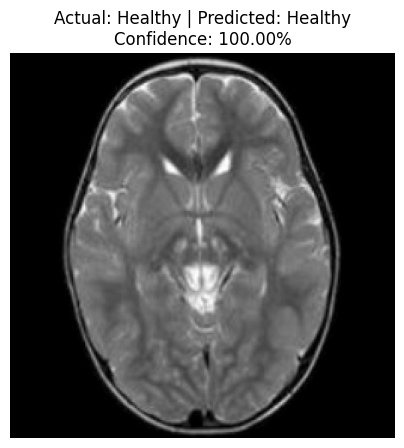


Image: pituitary (318).jpg
Actual    : Tumor
Prediction: Tumor
Confidence: 100.00%
Result    : ✅ CORRECT


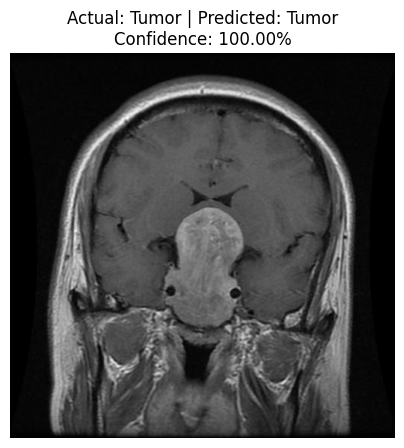


Image: meningioma (158).jpg
Actual    : Tumor
Prediction: Tumor
Confidence: 100.00%
Result    : ✅ CORRECT


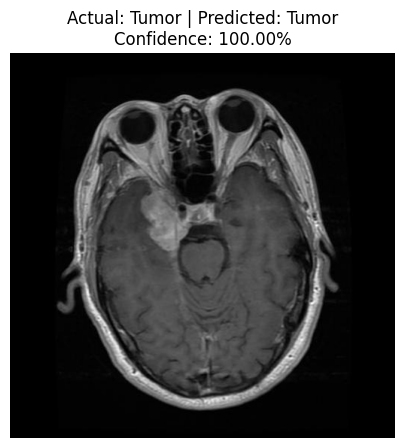


Image: mri_healthy (41).jpg
Actual    : Healthy
Prediction: Healthy
Confidence: 99.99%
Result    : ✅ CORRECT


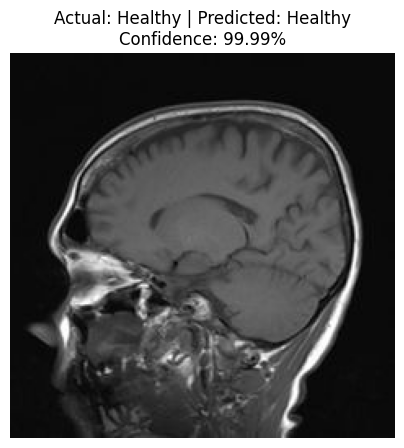


Image: mri_healthy (554).jpg
Actual    : Healthy
Prediction: Healthy
Confidence: 100.00%
Result    : ✅ CORRECT


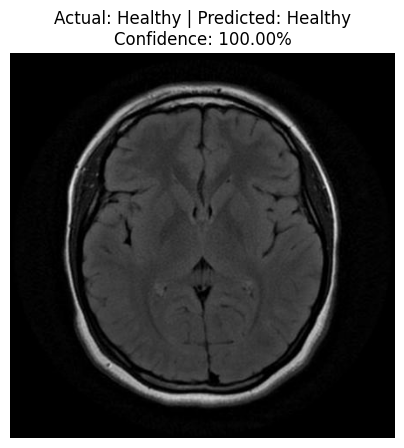


INTERNAL INDIVIDUAL TEST COMPLETE


In [27]:
# ============================================================
# MODEL 2A - MRI TUMOR DETECTION
# STEP 22: INDIVIDUAL INTERNAL MRI TEST
# ============================================================

import torch
import matplotlib.pyplot as plt
from PIL import Image

CLASS_NAMES = {
    0: "Healthy",
    1: "Tumor"
}


def predict_mri(image_path):

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = Image.open(
        image_path
    ).convert("RGB")

    original_image = image.copy()

    # --------------------------------------------------------
    # Apply test transformation
    # --------------------------------------------------------

    image_tensor = test_transform(
        image
    )

    # --------------------------------------------------------
    # Add batch dimension
    # --------------------------------------------------------

    image_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = prediction.item()
    confidence_value = confidence.item() * 100

    return (
        original_image,
        predicted_class,
        confidence_value
    )


# ============================================================
# TEST 5 RANDOM INTERNAL TEST IMAGES
# ============================================================

import random

random.seed(42)

sample_indices = random.sample(
    range(len(test_df)),
    5
)

print("=" * 70)
print("MODEL 2A - INTERNAL INDIVIDUAL IMAGE TEST")
print("=" * 70)

for index in sample_indices:

    row = test_df.iloc[index]

    image_path = row["filepath"]

    actual_label = row["label"]

    original_image, predicted_label, confidence = predict_mri(
        image_path
    )

    actual_class = CLASS_NAMES[
        actual_label
    ]

    predicted_class = CLASS_NAMES[
        predicted_label
    ]

    print("\nImage:", os.path.basename(image_path))
    print("Actual    :", actual_class)
    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

    if actual_label == predicted_label:
        print("Result    : ✅ CORRECT")
    else:
        print("Result    : ❌ INCORRECT")

    plt.figure(figsize=(5, 5))

    plt.imshow(original_image)

    plt.title(
        f"Actual: {actual_class} | "
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

print("\n" + "=" * 70)
print("INTERNAL INDIVIDUAL TEST COMPLETE")
print("=" * 70)

UPLOAD TWO EXTERNAL MRI IMAGES


Saving images.jpg to images.jpg
Saving MRI_of_Human_Brain.jpg to MRI_of_Human_Brain.jpg

Uploaded files:
 - images.jpg
 - MRI_of_Human_Brain.jpg


EXTERNAL MRI PREDICTIONS

Image: images.jpg
Prediction : Tumor
Confidence : 99.97%


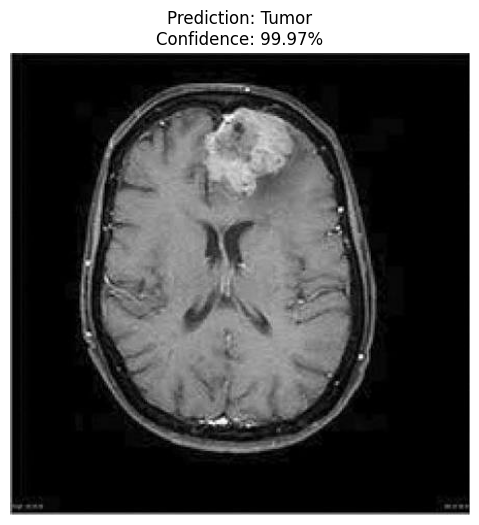


Image: MRI_of_Human_Brain.jpg
Prediction : Healthy
Confidence : 98.23%


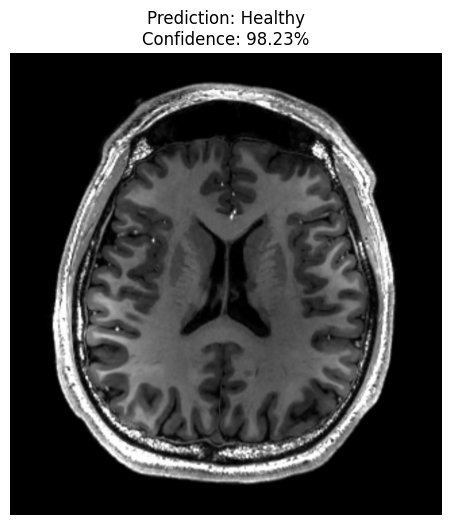


EXTERNAL TEST COMPLETE


In [28]:
# ============================================================
# MODEL 2A - EXTERNAL MRI TEST
# STEP 23: TEST TWO EXTERNAL IMAGES
# ============================================================

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch
import os

print("=" * 70)
print("UPLOAD TWO EXTERNAL MRI IMAGES")
print("=" * 70)

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print(" -", filename)


# ============================================================
# PREDICTION FUNCTION
# ============================================================

CLASS_NAMES = {
    0: "Healthy",
    1: "Tumor"
}


def predict_external_mri(image_path):

    # Load image
    image = Image.open(
        image_path
    ).convert("RGB")

    # Keep original for display
    original_image = image.copy()

    # Apply exactly the same preprocessing
    image_tensor = test_transform(
        image
    )

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    # Prediction
    model.eval()

    with torch.no_grad():

        outputs = model(
            image_tensor
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_label = prediction.item()

    confidence_value = (
        confidence.item() * 100
    )

    return (
        original_image,
        predicted_label,
        confidence_value
    )


# ============================================================
# TEST ALL UPLOADED IMAGES
# ============================================================

print("\n")
print("=" * 70)
print("EXTERNAL MRI PREDICTIONS")
print("=" * 70)

for filename in uploaded.keys():

    image_path = filename

    (
        image,
        predicted_label,
        confidence
    ) = predict_external_mri(
        image_path
    )

    predicted_class = CLASS_NAMES[
        predicted_label
    ]

    print("\nImage:", filename)
    print("Prediction :", predicted_class)
    print(
        f"Confidence : {confidence:.2f}%"
    )

    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(figsize=(6, 6))

    plt.imshow(image)

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")

    plt.show()

print("\n" + "=" * 70)
print("EXTERNAL TEST COMPLETE")
print("=" * 70)

In [29]:
# ============================================================
# MODEL 2A - SAVE & DOWNLOAD FINAL MODEL
# ============================================================

import os
from google.colab import files

MODEL_PATH = "/content/BrainTumor_MRI_Detector_Best.pth"

# Verify model exists
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}"
    )

# Display model information
model_size_mb = (
    os.path.getsize(MODEL_PATH)
    / (1024 * 1024)
)

print("=" * 70)
print("MODEL 2A - FINAL MODEL")
print("=" * 70)

print("\nModel name:")
print("BrainTumor_MRI_Detector_Best.pth")

print("\nArchitecture:")
print("EfficientNet-B0")

print("\nClasses:")
print("0 → Healthy")
print("1 → Tumor")

print("\nInput size:")
print("224 × 224 RGB")

print("\nBest validation accuracy:")
print(
    f"{checkpoint['val_accuracy']:.2f}%"
)

print("\nModel size:")
print(
    f"{model_size_mb:.2f} MB"
)

print("\nModel path:")
print(MODEL_PATH)

print("\n" + "=" * 70)
print("DOWNLOADING MODEL")
print("=" * 70)

files.download(MODEL_PATH)

MODEL 2A - FINAL MODEL

Model name:
BrainTumor_MRI_Detector_Best.pth

Architecture:
EfficientNet-B0

Classes:
0 → Healthy
1 → Tumor

Input size:
224 × 224 RGB

Best validation accuracy:
99.87%

Model size:
46.37 MB

Model path:
/content/BrainTumor_MRI_Detector_Best.pth

DOWNLOADING MODEL


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>